# AyurNLP – AI-Powered Patient Case-Taking & Symptom Classification System

### Problem Statement
Patient Case-Taking Software

### Objective
To develop a prototype system that uses Natural Language Processing (NLP)
and Machine Learning to classify patient-reported complaints into
predefined symptom categories.

### AI Technologies
- Natural Language Processing (NLP)
- TF-IDF Vectorization
- Logistic Regression

### Technology
- Python
- Pandas
- NumPy
- Scikit-learn
- Google Colab

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# Create a small prototype dataset

data = {
    "complaint": [
        "cough and throat irritation",
        "cold and breathing difficulty",
        "dry cough and chest discomfort",
        "runny nose and sore throat",
        "stomach pain and vomiting",
        "abdominal pain and indigestion",
        "nausea and stomach discomfort",
        "loose motion and stomach pain",
        "skin itching and red rash",
        "dry skin and itching",
        "skin redness and irritation",
        "itchy skin with small rashes",
        "joint pain and muscle pain",
        "knee pain and joint stiffness",
        "back pain and muscle pain",
        "shoulder pain and stiffness",
        "headache and tiredness",
        "mild headache and weakness",
        "body tiredness and fatigue",
        "feeling weak and tired"
    ],

    "category": [
        "Respiratory",
        "Respiratory",
        "Respiratory",
        "Respiratory",
        "Digestive",
        "Digestive",
        "Digestive",
        "Digestive",
        "Skin",
        "Skin",
        "Skin",
        "Skin",
        "Musculoskeletal",
        "Musculoskeletal",
        "Musculoskeletal",
        "Musculoskeletal",
        "General",
        "General",
        "General",
        "General"
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")

Dataset created successfully!


In [3]:
df

,complaint,category
0,cough and throat irritation,Respiratory
1,cold and breathing difficulty,Respiratory
2,dry cough and chest discomfort,Respiratory
3,runny nose and sore throat,Respiratory
4,stomach pain and vomiting,Digestive
5,abdominal pain and indigestion,Digestive
6,nausea and stomach discomfort,Digestive
7,loose motion and stomach pain,Digestive
8,skin itching and red rash,Skin
9,dry skin and itching,Skin


In [4]:
# Check the basic information about our dataset

print("Number of records:", len(df))
print("Number of categories:", df["category"].nunique())

print("\nCategories:")
print(df["category"].unique())

print("\nMissing values:")
print(df.isnull().sum())

Number of records: 20
Number of categories: 5

Categories:
['Respiratory' 'Digestive' 'Skin' 'Musculoskeletal' 'General']

Missing values:
complaint    0
category     0
dtype: int64


In [6]:
# Text preprocessing function

def preprocess_text(text):
    text = text.lower()
    text = text.strip()
    return text

# Apply preprocessing to the complaint column
df["cleaned_complaint"] = df["complaint"].apply(preprocess_text)

# Display original and cleaned text
df[["complaint", "cleaned_complaint"]].head(10)

,complaint,cleaned_complaint
0,cough and throat irritation,cough and throat irritation
1,cold and breathing difficulty,cold and breathing difficulty
2,dry cough and chest discomfort,dry cough and chest discomfort
3,runny nose and sore throat,runny nose and sore throat
4,stomach pain and vomiting,stomach pain and vomiting
5,abdominal pain and indigestion,abdominal pain and indigestion
6,nausea and stomach discomfort,nausea and stomach discomfort
7,loose motion and stomach pain,loose motion and stomach pain
8,skin itching and red rash,skin itching and red rash
9,dry skin and itching,dry skin and itching


In [7]:
# Separate the input (X) and output (y)

X = df["cleaned_complaint"]
y = df["category"]

print("Input (X):")
print(X.head())

print("\nOutput (y):")
print(y.head())

Input (X):
0       cough and throat irritation
1     cold and breathing difficulty
2    dry cough and chest discomfort
3        runny nose and sore throat
4         stomach pain and vomiting
Name: cleaned_complaint, dtype: object

Output (y):
0    Respiratory
1    Respiratory
2    Respiratory
3    Respiratory
4      Digestive
Name: category, dtype: object


In [9]:
# Split the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 15
Testing samples: 5


In [10]:
# Convert text into numerical features using TF-IDF

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF transformation completed!")
print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

TF-IDF transformation completed!
Training feature shape: (15, 35)
Testing feature shape: (5, 35)


In [11]:
# Train the Logistic Regression model

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [12]:
# Evaluate the trained model

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Model Accuracy: 1.0

Classification Report:
                 precision    recall  f1-score   support

      Digestive       1.00      1.00      1.00         1
        General       1.00      1.00      1.00         1
Musculoskeletal       1.00      1.00      1.00         1
    Respiratory       1.00      1.00      1.00         1
           Skin       1.00      1.00      1.00         1

       accuracy                           1.00         5
      macro avg       1.00      1.00      1.00         5
   weighted avg       1.00      1.00      1.00         5



In [13]:
# Test the model with a new complaint

new_complaint = ["I have severe stomach pain and nausea"]

# Preprocess the new complaint
cleaned_complaint = [preprocess_text(new_complaint[0])]

# Convert the complaint into TF-IDF features
new_complaint_tfidf = vectorizer.transform(cleaned_complaint)

# Predict the category
prediction = model.predict(new_complaint_tfidf)

print("Patient Complaint:", new_complaint[0])
print("Predicted Category:", prediction[0])

Patient Complaint: I have severe stomach pain and nausea
Predicted Category: Digestive


In [14]:
# Test the model with multiple new complaints

test_complaints = [
    "I have cough and throat irritation",
    "I have stomach pain and nausea",
    "My skin is itchy and has a red rash",
    "I have knee pain and joint stiffness",
    "I feel weak and tired"
]

for complaint in test_complaints:
    cleaned_text = [preprocess_text(complaint)]
    complaint_tfidf = vectorizer.transform(cleaned_text)
    prediction = model.predict(complaint_tfidf)

    print("Complaint:", complaint)
    print("Predicted Category:", prediction[0])
    print("-" * 50)

Complaint: I have cough and throat irritation
Predicted Category: Respiratory
--------------------------------------------------
Complaint: I have stomach pain and nausea
Predicted Category: Digestive
--------------------------------------------------
Complaint: My skin is itchy and has a red rash
Predicted Category: Skin
--------------------------------------------------
Complaint: I have knee pain and joint stiffness
Predicted Category: Musculoskeletal
--------------------------------------------------
Complaint: I feel weak and tired
Predicted Category: General
--------------------------------------------------


In [15]:
# Check prediction and confidence for a new complaint

new_complaint = "I have stomach pain and nausea"

cleaned_text = [preprocess_text(new_complaint)]
complaint_tfidf = vectorizer.transform(cleaned_text)

prediction = model.predict(complaint_tfidf)
probabilities = model.predict_proba(complaint_tfidf)

confidence = max(probabilities[0]) * 100

print("Patient Complaint:", new_complaint)
print("Predicted Category:", prediction[0])
print("Confidence:", round(confidence, 2), "%")

Patient Complaint: I have stomach pain and nausea
Predicted Category: Digestive
Confidence: 37.36 %


In [16]:
# Interactive patient complaint prediction

patient_complaint = input("Enter the patient's complaint: ")

cleaned_text = [preprocess_text(patient_complaint)]
complaint_tfidf = vectorizer.transform(cleaned_text)

prediction = model.predict(complaint_tfidf)
probabilities = model.predict_proba(complaint_tfidf)

confidence = max(probabilities[0]) * 100

print("\nPatient Complaint:", patient_complaint)
print("Predicted Category:", prediction[0])
print("Confidence:", round(confidence, 2), "%")

Enter the patient's complaint: i have severe backpain and muscle stiffness

Patient Complaint: i have severe backpain and muscle stiffness
Predicted Category: Musculoskeletal
Confidence: 33.19 %


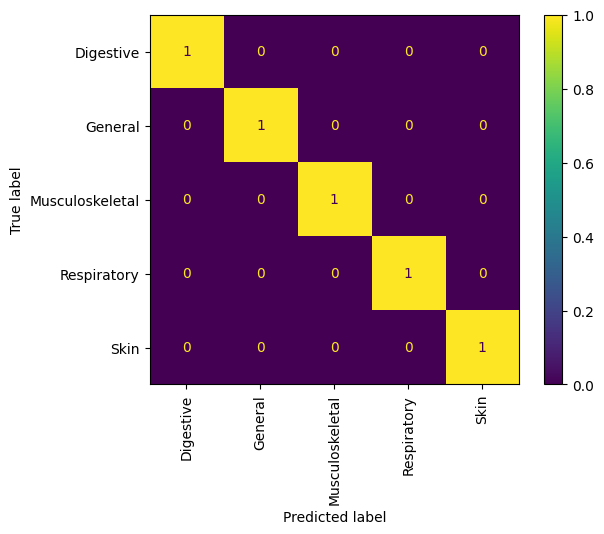

In [17]:
# Display the confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation="vertical"
)

In [18]:
# Final AyurNLP demonstration

print("==============================================")
print("       AyurNLP - Patient Case-Taking AI")
print("==============================================")

complaint = input("\nEnter patient complaint: ")

# Preprocess the complaint
cleaned_complaint = [preprocess_text(complaint)]

# Convert text into TF-IDF features
complaint_tfidf = vectorizer.transform(cleaned_complaint)

# Predict category
prediction = model.predict(complaint_tfidf)

# Calculate confidence
probabilities = model.predict_proba(complaint_tfidf)
confidence = max(probabilities[0]) * 100

print("\n----------- Analysis Result -----------")
print("Patient Complaint :", complaint)
print("Predicted Category:", prediction[0])
print("Confidence        :", round(confidence, 2), "%")
print("---------------------------------------")

print("\nNote: This prototype performs symptom-category")
print("classification and does not provide medical diagnosis.")

       AyurNLP - Patient Case-Taking AI

Enter patient complaint: i have cough ,cold and throat irritation

----------- Analysis Result -----------
Patient Complaint : i have cough ,cold and throat irritation
Predicted Category: Respiratory
Confidence        : 41.5 %
---------------------------------------

Note: This prototype performs symptom-category
classification and does not provide medical diagnosis.


In [ ]:
# Export the trained ML objects used by this notebook
import os
import pickle

project_dir = os.path.abspath(os.path.dirname(os.getcwd())) if os.path.basename(os.getcwd()) == "backend" else os.getcwd()
backend_dir = os.path.join(project_dir, "backend")
os.makedirs(backend_dir, exist_ok=True)

with open(os.path.join(backend_dir, "model.pkl"), "wb") as model_file:
    pickle.dump(model, model_file)

with open(os.path.join(backend_dir, "vectorizer.pkl"), "wb") as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)

print("Exported model.pkl and vectorizer.pkl to:", backend_dir)